# Классификация страниц: статья или не статья

Ноутбук показывает полный цикл построения базовой модели бинарной классификации страниц.

В работе выполняются следующие шаги:

1. загрузка и первичная подготовка размеченного набора данных;
2. нормализация URL и объединение текстовых признаков в единое поле `text_all`;
3. разведочный анализ данных и проверка качества разметки;
4. разделение выборки на обучающую и тестовую части без потери индексов;
5. обучение модели `TF-IDF + LogisticRegression` на фиксированных параметрах;
6. оценка качества модели на тестовой выборке;
7. подбор рабочего порога `threshold`;
8. анализ ошибок модели;
9. сохранение обученных артефактов для дальнейшего применения в проекте.

Модель решает вспомогательную задачу отбора страниц со статьями. Итоговое решение рекомендуется использовать вместе с правилами и ручной проверкой спорных случаев.


In [1]:

import re
import numpy as np
import pandas as pd
from pathlib import Path
from urllib.parse import urlparse


# Загрузка датасета
df = pd.read_csv('train_dataset_combined_with_target.csv')

# Гарантируем наличие нужных столбцов
for col in ['url', 'title', 'h1', 'meta_description', 'manual_key', 'is_selected_article']:
    if col not in df.columns:
        df[col] = ''

# Приводим текстовые поля к единому виду
for col in ['url', 'title', 'h1', 'meta_description', 'manual_key']:
    df[col] = df[col].fillna('').astype(str).str.strip()

# Приводим целевой признак к бинарному формату
df['is_selected_article'] = pd.to_numeric(df['is_selected_article'], errors='coerce').fillna(0).astype(int)

def normalize_url(url: str) -> str:
    # Убираем мусорные хвосты и лишние символы
    if url is None:
        return ''
    url = str(url).strip()
    url = url.replace('"text/html', '').replace("'text/html", '').replace('text/html', '')
    url = url.strip().strip('"').strip("'").strip()
    url = re.sub(r'[,#?&\s]+$', '', url)
    return url

def normalize_url_for_text(url: str) -> str:
    # Превращаем URL в текстовый признак для модели
    url = normalize_url(url).lower()
    if not url:
        return ''
    try:
        parsed = urlparse(url)
        domain = parsed.netloc.replace('www.', '')
        path = parsed.path
        path = re.sub(r'/text/html/?$', '', path)
        path = re.sub(r'/index\.html?$', '', path)
        text = f'{domain} {path}'
    except Exception:
        text = url

    text = text.replace('/', ' ').replace('-', ' ').replace('_', ' ')
    text = re.sub(r'\.html?$', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['url'] = df['url'].apply(normalize_url)
df['url_text'] = df['url'].map(normalize_url_for_text)

# Объединяем текстовые признаки в одно поле
# Это основной вход для TF-IDF-векторизации
df_text = (
    df['url_text'] + ' [SEP] ' +
    df['title'] + ' [SEP] ' +
    df['h1'] + ' [SEP] ' +
    df['meta_description']
).str.strip()
df['text_all'] = df_text

# Дополнительные признаки для EDA
for col in ['url', 'title', 'h1', 'meta_description', 'manual_key', 'text_all']:
    df[f'{col}_len'] = df[col].astype(str).str.len()

df['domain'] = df['url'].map(lambda x: urlparse(x).netloc.replace('www.', '') if str(x).strip() else '')

# Рабочий датафрейм только с нужными полями
model_df = df[[
    'url', 'url_text', 'title', 'h1', 'meta_description',
    'manual_key', 'text_all', 'is_selected_article'
]].copy()

print('Форма train-set:', df.shape)
display(model_df.head(10))
display(df['is_selected_article'].value_counts())


Форма train-set: (87207, 17)


,url,url_text,title,h1,meta_description,manual_key,text_all,is_selected_article
0,https://afitness.ru/fitness-magazine/expertise/,afitness.ru fitness magazine expertise,Экспертные статьи фитнес-тренеров о спорте и п...,,Экспертные статьи фитнес-инструкторов о тренир...,,afitness.ru fitness magazine expertise [SEP] Э...,0
1,https://afitness.ru/corporate_fitness/,afitness.ru corporate fitness,Корпоративный спорт в фитнес-клубах A-Fitness,Корпоративный фитнес в A-Fitness,Фитнес для компании от 5 человек в премиальных...,,afitness.ru corporate fitness [SEP] Корпоратив...,0
2,https://afitness.ru/fitness-magazine/chto_tako...,afitness.ru fitness magazine chto takoe traste...,Что такое трастеры с гантелями и зачем нужны у...,Что такое трастеры и зачем нужны упражнения?,"Разберём что такое упражнение трастеры, их пре...",трастеры с гантелями,afitness.ru fitness magazine chto takoe traste...,1
3,https://afitness.ru/fitness-magazine/glavnye_s...,afitness.ru fitness magazine glavnye sposoby p...,"Как мотивировать себя, чтобы не забросить трен...",Главные способы побороть себя и не бросать тре...,Почему люди бросают тренироваться? Несколько с...,,afitness.ru fitness magazine glavnye sposoby p...,0
4,https://afitness.ru/fitness-magazine/10-vredny...,afitness.ru fitness magazine 10 vrednyh privyc...,"10 вредных привычек, которые убивают пользу тр...","10 вредных привычек, которые убивают пользу тр...",В этой статье мы рассмотрим какие вредные прив...,,afitness.ru fitness magazine 10 vrednyh privyc...,0
5,https://afitness.ru/fitness-magazine/kak-prevr...,afitness.ru fitness magazine kak prevratit rut...,Как превратить рутину в адреналин в стенах тре...,Долой скуку или как превратить рутину на трени...,Как превратить рутину в адреналин в стенах тре...,,afitness.ru fitness magazine kak prevratit rut...,0
6,https://rostov.afitness.ru/,rostov.afitness.ru,Фитнес-клуб с бассейном A-Fitness Северный - п...,A-Fitness Северный Фитнес-клуб с бассейном,A-Fitness Северный - спортивный клуб с бассейн...,,rostov.afitness.ru [SEP] Фитнес-клуб с бассейн...,0
7,https://afitness.ru/fitness-magazine/chto_tako...,afitness.ru fitness magazine chto takoe trenaz...,Что такое тренажер гравитрон и для чего исполь...,Что такое тренажер гравитрон и для чего исполь...,"Гравитрон — это тренажер, используемый для под...",тренажер гравитрон,afitness.ru fitness magazine chto takoe trenaz...,1
8,https://afitness.ru/fitness-magazine/polza_jog...,afitness.ru fitness magazine polza jogi dlya b...,Польза тренировок по йоге для беременных,Польза йоги для беременных и когда лучше начат...,Занятия йогой во время беременности могут быть...,йога для беременных,afitness.ru fitness magazine polza jogi dlya b...,1
9,https://afitness.ru/fitness-magazine/soptivnye...,afitness.ru fitness magazine soptivnye rezulta...,Как новичкам улучшить свои спортивные результа...,Что делать новичкам чтобы улучшить свои спорти...,"Рассмотрим ключевые шаги, которые помогут нови...",улучшить спортивные результаты,afitness.ru fitness magazine soptivnye rezulta...,1


is_selected_article
0    83656
1     3551
Name: count, dtype: int64

## Разведочный анализ данных

На этом этапе оцениваются размер выборки, баланс классов, заполненность полей и базовые характеристики текстовых признаков.

EDA помогает понять:

- насколько выборка несбалансирована;
- есть ли пропуски в важных полях;
- отличаются ли статьи и не-статьи по длине и структуре текста;
- нет ли признаков неполной ручной разметки.


In [2]:
# Общая информация о датасете
summary_df = pd.DataFrame({
    'metric': [
        'rows_total',
        'article_count',
        'non_article_count',
        'article_share',
        'non_article_share'
    ],
    'value': [
        len(df),
        int(df['is_selected_article'].eq(1).sum()),
        int(df['is_selected_article'].eq(0).sum()),
        round(df['is_selected_article'].eq(1).mean(), 4),
        round(df['is_selected_article'].eq(0).mean(), 4)
    ]
})

print('Общая информация о датасете')
display(summary_df)

Общая информация о датасете


,metric,value
0,rows_total,87207.0000
1,article_count,3551.0000
2,non_article_count,83656.0000
3,article_share,0.0407
4,non_article_share,0.9593


Выборка содержит выраженный дисбаланс классов. Доля статей значительно ниже доли не статей, поэтому при оценке качества модели недостаточно использовать только accuracy, требуется анализ precision, recall, f1-score и roc-auc.

In [3]:
# Заполненность ключевых полей
missing_df = pd.DataFrame({
    'column': ['url', 'title', 'h1', 'meta_description', 'manual_key', 'text_all'],
    'empty_share': [
        round(df['url'].eq('').mean(), 4),
        round(df['title'].eq('').mean(), 4),
        round(df['h1'].eq('').mean(), 4),
        round(df['meta_description'].eq('').mean(), 4),
        round(df['manual_key'].eq('').mean(), 4),
        round(df['text_all'].eq('').mean(), 4)
    ]
})

print('\nЗаполненность ключевых полей')
display(missing_df)



Заполненность ключевых полей


,column,empty_share
0,url,0.0000
1,title,0.3399
2,h1,0.4532
3,meta_description,0.5927
4,manual_key,0.9593
5,text_all,0.0000


Признаки заполнены неравномерно. Поле url присутствует почти всегда, тогда как title, h1 и особенно meta_description могут отсутствовать у значительной части страниц. Это подтверждает целесообразность объединения нескольких полей в общий признак text_all

In [4]:
# Сравнение длин текстовых полей по классам
eda_len_df = df.groupby('is_selected_article')[['title_len', 'h1_len', 'meta_description_len', 'text_all_len']].agg(['mean', 'median'])

print('\nСравнение длин текстовых полей по классам')
display(eda_len_df)


Сравнение длин текстовых полей по классам


title_len            h1_len        meta_description_len  \
                          mean median       mean median                 mean   
is_selected_article                                                            
0                    51.585338   54.0  27.861217   13.0            66.688857   
1                    69.230076   69.0  48.799211   48.0           120.279076   

                           text_all_len         
                    median         mean median  
is_selected_article                             
0                      0.0   217.828632  219.0  
1                    142.0   303.006759  315.0

Cтраницы, отнесенные к статьям, в среднем содержат более длинные текстовые поля, чем страницы, не являющиеся статьями. Наиболее заметная разница наблюдается по совокупному текстовому признаку text_all, что указывает на наличие различий между классами уже на уровне текстовой структуры

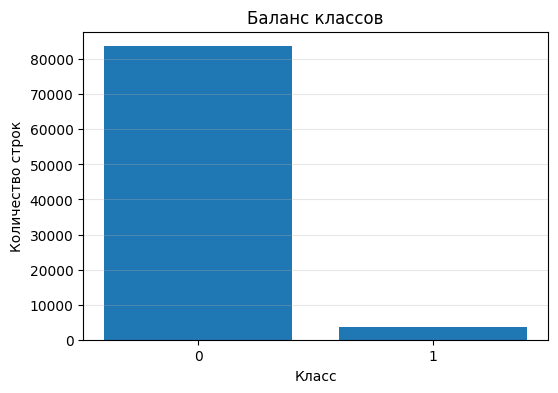

<Figure size 800x500 with 0 Axes>

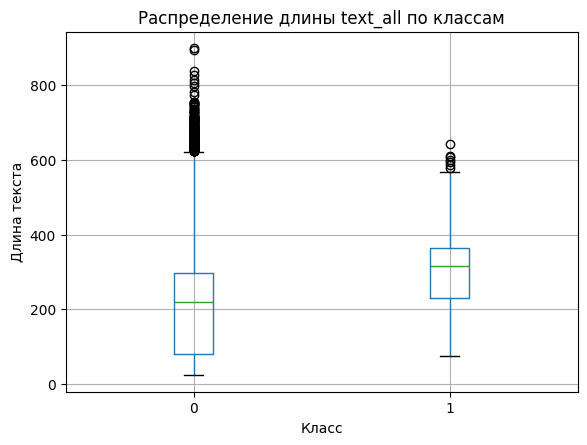

In [5]:

import matplotlib.pyplot as plt

# Баланс классов
class_counts = df['is_selected_article'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
plt.bar(class_counts.index.astype(str), class_counts.values)
plt.title('Баланс классов')
plt.xlabel('Класс')
plt.ylabel('Количество строк')
plt.grid(axis='y', alpha=0.3)
plt.show()

# Распределение длины text_all по классам
plt.figure(figsize=(8, 5))
df.boxplot(column='text_all_len', by='is_selected_article')
plt.title('Распределение длины text_all по классам')
plt.suptitle('')
plt.xlabel('Класс')
plt.ylabel('Длина текста')
plt.show()

У класса 1 медиана длины text_all выше, чем у класса 0. Это значит, что страницы, размеченные как статьи, в среднем содержат более длинный текстовый блок.

Также у класса 1 распределение выглядит более компактным и сосредоточенным в среднем диапазоне значений, тогда как у класса 0 разброс шире и наблюдается большое число выбросов. Это говорит о том, что среди не-статей встречаются как очень короткие, так и достаточно длинные страницы.

При этом диапазоны все равно пересекаются. Значит, длина текста действительно полезна как признак, но ее недостаточно для точного разделения классов. Иначе говоря, только по объему текста надежно определить статью нельзя.

In [6]:
# Потенциально недоразмеченные строки
possible_missed_df = df[
    (df['is_selected_article'] == 0) &
    (df['manual_key'].eq('')) &
    (df['text_all_len'] >= df['text_all_len'].quantile(0.75))
].copy()

print('Потенциально недоразмеченных строк:', len(possible_missed_df))
display(possible_missed_df[['url', 'title', 'h1', 'meta_description', 'text_all_len']].head(20))

Потенциально недоразмеченных строк: 19900


,url,title,h1,meta_description,text_all_len
3,https://afitness.ru/fitness-magazine/glavnye_s...,"Как мотивировать себя, чтобы не забросить трен...",Главные способы побороть себя и не бросать тре...,Почему люди бросают тренироваться? Несколько с...,383
6,https://rostov.afitness.ru/,Фитнес-клуб с бассейном A-Fitness Северный - п...,A-Fitness Северный Фитнес-клуб с бассейном,A-Fitness Северный - спортивный клуб с бассейн...,343
21,https://afitness.ru/fitness-magazine/beg-kak-s...,Является ли бег лучшим способом похудеть?,"Бег, как лучший способ похудеть - так ли это?",Бег является эффективным средством для снижени...,307
27,https://afitness.ru/fitness-magazine/funkciona...,Чем полезен функциональный тренинг и почему ег...,Функциональные тренировки: почему все о них го...,Функциональный тренинг перестал быть просто мо...,445
29,https://afitness.ru/fitness-magazine/chto_tako...,Берпи: множество полезных движений в одном упр...,Что такое упражнение бёрпи и зачем его делать?,Берпи - универсальное и многофункциональное уп...,320
33,https://afitness.ru/fitness-magazine/chto-tako...,Что такое рекомпозиция тела?,Что такое рекомпозиция тела?,Рекомпозиция тела – процесс возрастания массы ...,325
44,https://afitness.ru/fitness-magazine/trenirovk...,Тренировка бодифлекс - что это такое и особенн...,Тренировка бодифлекс (Bodyflex) – правильно ды...,Техника бодифлекс основана на диафрагмальном д...,430
46,https://afitness.ru/fitness-magazine/medball_f...,Что такое медбол в фитнесе и как правильно тре...,Медицинский мяч (медбол) - что это такое и как...,Метбол - это спортивный снаряд для восстановле...,359
48,https://ufa.afitness.ru/,Фитнес-клуб с бассейном A-Fitness Бикбая - пре...,A-Fitness Бикбая Фитнес-клуб с бассейном,A-Fitness Бикбая - спортивный клуб с бассейном...,311
50,https://spb.afitness.ru/marata/,Фитнес-клуб с бассейном A-Fitness Марата - пре...,A-Fitness Марата Фитнес-клуб с бассейном,A-Fitness Марата - спортивный клуб с бассейном...,376


Анализ страниц, отнесенных к классу не-статей и не имеющих вручную заданного ключа, показал наличие большого числа записей с достаточно длинным текстовым содержанием. Среди них встречаются страницы, которые по заголовкам, подзаголовкам и описаниям имеют явные признаки информационных материалов. Это подтверждает, что в исходной ручной разметке могут присутствовать пропуски, а часть объектов класса 0 потенциально относится к статьям. Следовательно, ошибки модели в подобных случаях могут быть связаны не только с особенностями алгоритма, но и с неполнотой обучающей выборки.

In [7]:

from sklearn.model_selection import train_test_split

# Делим данные на train и test с сохранением исходных индексов
train_idx, test_idx = train_test_split(
    model_df.index,
    test_size=0.2,
    random_state=42,
    stratify=model_df['is_selected_article']
)

train_df = model_df.loc[train_idx].copy()
test_df = model_df.loc[test_idx].copy()

X_train = train_df['text_all'].astype(str)
y_train = train_df['is_selected_article'].astype(int)

X_test = test_df['text_all'].astype(str)
y_test = test_df['is_selected_article'].astype(int)

print('Train:', len(train_df))
print('Test:', len(test_df))


Train: 69765
Test: 17442


In [8]:

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

# Векторизация текстов TF-IDF
vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    max_df=0.95,
    max_features=100000,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Обучение логистической регрессии на фиксированных параметрах
model = LogisticRegression(
    C=10.0,
    max_iter=3000,
    class_weight='balanced',
    random_state=42
)

model.fit(X_train_vec, y_train)

y_proba = model.predict_proba(X_test_vec)[:, 1]
y_pred_05 = (y_proba >= 0.50).astype(int)

print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print()
print('Метрики при threshold = 0.50')
print(classification_report(y_test, y_pred_05, digits=4, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred_05))


ROC-AUC: 0.9660096786792954

Метрики при threshold = 0.50
              precision    recall  f1-score   support

           0     0.9895    0.9540    0.9714     16732
           1     0.4122    0.7606    0.5347       710

    accuracy                         0.9461     17442
   macro avg     0.7008    0.8573    0.7530     17442
weighted avg     0.9660    0.9461    0.9536     17442

Confusion matrix:
[[15962   770]
 [  170   540]]


Результаты классификации при threshold = 0.50 показывают, что модель в целом хорошо разделяет классы, о чем свидетельствует высокое значение ROC-AUC = 0.966. Однако из-за выраженного дисбаланса выборки итоговая accuracy = 0.946 не может рассматриваться как основной показатель качества. Для класса статей (1) модель демонстрирует recall = 0.7606, то есть находит значительную часть статей, но precision = 0.4122 остается заметно ниже, что указывает на большое число ложноположительных срабатываний. Это означает, что модель склонна относить к статьям часть страниц, которые в разметке помечены как не-статьи. С учетом ранее выявленных потенциально недоразмеченных объектов такая особенность может быть связана не только с ошибками алгоритма, но и с неполнотой исходной ручной разметки.

In [9]:

import pandas as pd
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Считаем метрики для набора порогов
thresholds = np.arange(0.05, 0.96, 0.05)

rows = []
for thr in thresholds:
    y_pred_thr = (y_proba >= thr).astype(int)
    rows.append({
        'threshold': round(float(thr), 2),
        'precision_1': precision_score(y_test, y_pred_thr, pos_label=1, zero_division=0),
        'recall_1': recall_score(y_test, y_pred_thr, pos_label=1, zero_division=0),
        'f1_1': f1_score(y_test, y_pred_thr, pos_label=1, zero_division=0),
        'accuracy': accuracy_score(y_test, y_pred_thr),
        'predicted_as_1': int((y_pred_thr == 1).sum())
    })

thr_df = pd.DataFrame(rows)
display(thr_df.sort_values(['f1_1', 'precision_1'], ascending=False).reset_index(drop=True).head(15))

best_f1_row = thr_df.sort_values(['f1_1', 'precision_1'], ascending=False).iloc[0]
best_f1_threshold = float(best_f1_row['threshold'])

print('Лучший threshold по F1:', best_f1_threshold)
print(best_f1_row)

candidate_df = thr_df[thr_df['precision_1'] >= 0.50].copy()
if len(candidate_df) > 0:
    best_prec_tradeoff = candidate_df.sort_values(['f1_1', 'recall_1'], ascending=False).iloc[0]
    print('\nХороший компромисс при precision >= 0.50:')
    print(best_prec_tradeoff)
else:
    print('\nНет порога, где precision >= 0.50')


,threshold,precision_1,recall_1,f1_1,accuracy,predicted_as_1
0,0.65,0.450906,0.666197,0.537806,0.953388,1049
1,0.70,0.465499,0.636620,0.537775,0.955452,971
2,0.55,0.423015,0.735211,0.537037,0.948400,1234
3,0.60,0.434291,0.702817,0.536848,0.950636,1149
4,0.50,0.412214,0.760563,0.534653,0.946107,1310
5,0.75,0.481229,0.595775,0.532410,0.957402,879
6,0.45,0.399275,0.776056,0.527273,0.943355,1380
7,0.40,0.383367,0.798592,0.518045,0.939514,1479
8,0.80,0.492288,0.539437,0.514785,0.958606,778
9,0.35,0.372849,0.823944,0.513383,0.936418,1569


Лучший threshold по F1: 0.65
threshold            0.650000
precision_1          0.450906
recall_1             0.666197
f1_1                 0.537806
accuracy             0.953388
predicted_as_1    1049.000000
Name: 12, dtype: float64

Хороший компромисс при precision >= 0.50:
threshold           0.850000
precision_1         0.506024
recall_1            0.473239
f1_1                0.489083
accuracy            0.959752
predicted_as_1    664.000000
Name: 16, dtype: float64


Лучший порог по F1-score равен 0.65, поскольку именно при нем достигается наиболее удачный баланс между precision и recall для класса статей. Более высокий порог позволяет повысить точность, но приводит к потере значительной части статей. Поэтому для основной версии модели целесообразно использовать threshold = 0.65, а более строгие значения порога рассматривать как дополнительный вариант отбора.

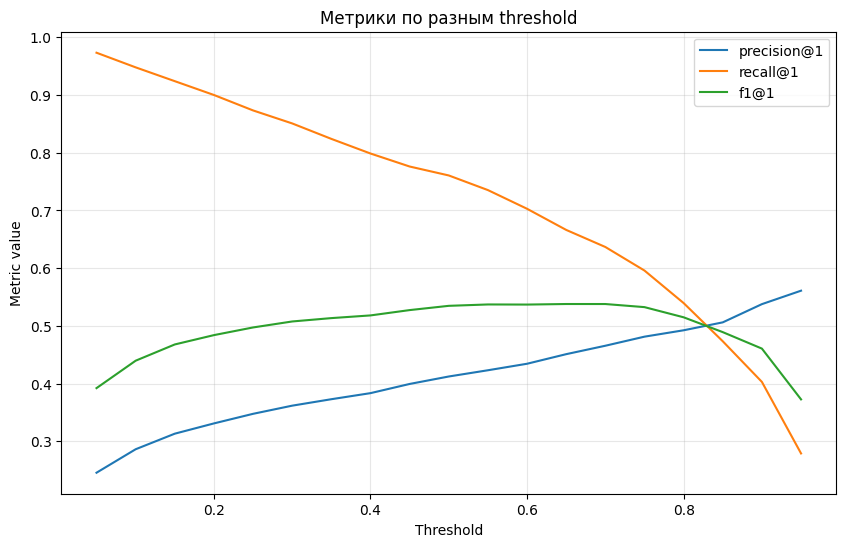

Threshold = 0.65
              precision    recall  f1-score   support

           0     0.9855    0.9656    0.9755     16732
           1     0.4509    0.6662    0.5378       710

    accuracy                         0.9534     17442
   macro avg     0.7182    0.8159    0.7566     17442
weighted avg     0.9638    0.9534    0.9576     17442

Confusion matrix:
[[16156   576]
 [  237   473]]


In [10]:

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

# Визуально сравниваем поведение метрик на разных порогах
plt.figure(figsize=(10, 6))
plt.plot(thr_df['threshold'], thr_df['precision_1'], label='precision@1')
plt.plot(thr_df['threshold'], thr_df['recall_1'], label='recall@1')
plt.plot(thr_df['threshold'], thr_df['f1_1'], label='f1@1')
plt.xlabel('Threshold')
plt.ylabel('Metric value')
plt.title('Метрики по разным threshold')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# В проекте выбирается рабочий порог с лучшим F1
CHOSEN_THRESHOLD = best_f1_threshold

y_pred = (y_proba >= CHOSEN_THRESHOLD).astype(int)

print('Threshold =', CHOSEN_THRESHOLD)
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print('Confusion matrix:')
print(confusion_matrix(y_test, y_pred))


На графике зависимости метрик от порога можно наблюдать точку пересечения кривых precision и recall, которая соответствует значению threshold около 0.83. В этой области точность и полнота модели становятся примерно равными. Однако данная точка не совпадает с оптимальным порогом классификации, поскольку максимум F1-score достигается при threshold = 0.65. Следовательно, равенство precision и recall само по себе не является критерием наилучшего выбора порога.

In [11]:

# Собираем тестовый датафрейм для анализа предсказаний
# Значения y_true приклеиваются без сброса индекса

eval_test_df = test_df.copy()

assert (eval_test_df['is_selected_article'].values == y_test.values).all(), 'Сбой: target в test_df не совпадает с y_test'

eval_test_df['y_true'] = y_test.values
eval_test_df['y_proba'] = y_proba
eval_test_df['y_pred'] = y_pred

print('len(y_test):', len(y_test))
print('len(y_proba):', len(y_proba))
print('len(eval_test_df):', len(eval_test_df))

display(eval_test_df[[
    'url', 'manual_key', 'is_selected_article', 'y_true', 'y_proba', 'y_pred'
]].head(10))

# Проверяем, нет ли положительных объектов с пустым manual_key
suspicious = eval_test_df[
    (eval_test_df['y_true'] == 1) &
    (
        eval_test_df['manual_key'].isna() |
        (eval_test_df['manual_key'].astype(str).str.strip() == '')
    )
].copy()


len(y_test): 17442
len(y_proba): 17442
len(eval_test_df): 17442


,url,manual_key,is_selected_article,y_true,y_proba,y_pred
37567,https://onfit.ru/upload/photo/8440/imagebigs/f...,,0,0,9.379200e-06,0
70170,https://t-j.ru/user3001560/,,0,0,3.778551e-06,0
80374,https://t-j.ru/user85736/,,0,0,2.807190e-06,0
46332,https://onfit.ru/upload/photo/8263/imagebigs/f...,,0,0,1.391067e-06,0
53935,http://pro.onfit.ru/user/login?destination=tax...,,0,0,6.552289e-07,0
11912,https://onfit.ru/news/test-drive-fitness-club-...,,0,0,6.046721e-03,0
36726,https://onfit.ru/upload/photo/8430/imagebigs/s...,,0,0,5.851626e-06,0
19953,https://onfit.ru/news/klientskie_dni_v_avguste...,,0,0,2.275760e-03,0
12929,https://onfit.ru/news/news_article31116.html,,0,0,3.512805e-04,0
79644,https://t-j.ru/ai-friend-ept/,,0,0,5.353211e-01,0


In [12]:

# Отдельно смотрим ложноположительные и ложноотрицательные примеры
fp_df = eval_test_df[(eval_test_df['y_true'] == 0) & (eval_test_df['y_pred'] == 1)].copy().sort_values('y_proba', ascending=False)
fn_df = eval_test_df[(eval_test_df['y_true'] == 1) & (eval_test_df['y_pred'] == 0)].copy().sort_values('y_proba', ascending=True)

print('Ложноположительные:', len(fp_df))
print('Ложноотрицательные:', len(fn_df))

display(fp_df[['url', 'title', 'h1', 'manual_key', 'y_true', 'y_proba', 'y_pred']].head(20))
display(fn_df[['url', 'title', 'h1', 'manual_key', 'y_true', 'y_proba', 'y_pred']].head(20))


Ложноположительные: 576
Ложноотрицательные: 237


,url,title,h1,manual_key,y_true,y_proba,y_pred
63783,https://t-j.ru/subsidia-zhku/,"Субсидия на оплату ЖКХ в 2025: кому положена, ...",Как получить субсидию на оплату коммунальных у...,,0,0.999351,1
67157,https://t-j.ru/soc-produkty/,"Социальные вклады и счета в 2025: как открыть,...",Как открыть социальный вклад и счет для малооб...,,0,0.998941,1
81569,https://t-j.ru/iis-faq/,"ИИС в 2025: что это и как работает, как и где ...",ИИС в вопросах и ответах,,0,0.998763,1
2469,https://cross-expert.com/uprazhneniya/skalolaz...,Как делать упражнение скалолаз: техника выполн...,Упражнение Скалолаз,,0,0.998361,1
33,https://afitness.ru/fitness-magazine/chto-tako...,Что такое рекомпозиция тела?,Что такое рекомпозиция тела?,,0,0.998046,1
6316,https://fitstars.ru/blog/workout/kak-pravilno-...,"Болгарские выпады — техника выполнения, какие ...",Как правильно делать болгарские выпады: упражн...,,0,0.997662,1
1622,https://cross-expert.com/uprazhneniya/gipereks...,"Гиперэкстензия: техника выполнения, виды и осо...",Гиперэкстензия (Hyperextension),,0,0.997328,1
6445,https://fitstars.ru/blog/workout/rastyazhka-pl...,Растяжка плеча — упражнения для растяжки плече...,"Растяжка плеча: упражнения, полезность и метод...",,0,0.996821,1
86096,https://bodymaster.ru/exercises/staticheskoe-u...,"Статическое упражнение ""Стульчик"": работающие ...","Статическое упражнение ""Стульчик""",,0,0.996698,1
65230,https://t-j.ru/socstrah/,"Льготы инвалидам 1, 2, 3 группы в 2025 году: к...",Какие льготы от государства положены людям с и...,,0,0.995972,1


,url,title,h1,manual_key,y_true,y_proba,y_pred
76525,https://t-j.ru/user15796/,"Маргинальная доходность: герой Т—Ж, 1 статья, ...",,Маргинальная доходность,1,0.000004,0
78956,https://t-j.ru/user2902793/,"Крис: герой Т—Ж, 2 статьи, 12 комментариев, 4 ...",,Ассертивность,1,0.000008,0
64043,https://t-j.ru/dear-therapist-invisible-for-gi...,Как научиться строить отношения,«Почти всю жизнь мне не отвечали взаимностью»:...,строить отношения,1,0.002897,0
4827,https://fitstars.ru/programs/pilates-with-ring,Пилатес с кольцом - программа тренировок от Ол...,Пилатес с кольцом,Пилатес с кольцом,1,0.008363,0
69580,https://t-j.ru/news/posobie-bezrabotnym/,"Пособие по безработице в 2020 году: размер, ус...",Пособие безработным повысили до 8000 ₽,Пособие по безработице,1,0.009815,0
83653,https://bodymaster.ru/training/program/obshchi...,Базовая тренировка плеч на массу для начинающи...,Базовая тренировка плеч на массу для начинающи...,тренировка плеч на массу,1,0.015508,0
68312,https://t-j.ru/short/moscow-region-reservoirs/,Водохранилища Москвы и Подмосковья: 12 красивы...,Водохранилища Москвы и Подмосковья: 12 мест дл...,Водохранилища Москвы,1,0.016927,0
3978,https://cross-expert.com/novosti/proshli-li-by...,Прошли ли бы вы допинг-контроль на соревновани...,Прошли ли бы вы допинг-контроль на соревновани...,допинг контроль,1,0.016984,0
72991,https://t-j.ru/list/best-rts/,Игры в жанре RTS: топ-25 лучших вариантов,25 лучших игр в жанре RTS,Игры RTS,1,0.020406,0
1420,https://cross-expert.com/partner/kurenie-i-ves...,Курение и вес: как бросить и не поправиться - ...,Курение и вес: как бросить и не поправиться,Курение и вес,1,0.020981,0


Модель чаще ошибается в сторону отнесения страниц к статьям, чем в сторону их пропуска. Однако анализ ложноположительных примеров показывает, что многие из них фактически похожи на реальные статьи. Это подтверждает гипотезу о неполной ручной разметке и показывает, что часть ошибок модели может быть содержательно оправданной.

In [13]:

import joblib
from pathlib import Path

# Сохраняем модель и служебные файлы для дальнейшего использования
MODEL_DIR = Path('model_artifacts')
MODEL_DIR.mkdir(parents=True, exist_ok=True)

CHOSEN_THRESHOLD = 0.65

joblib.dump(model, MODEL_DIR / 'article_selector_logreg.joblib')
joblib.dump(vectorizer, MODEL_DIR / 'article_selector_tfidf.joblib')
joblib.dump(CHOSEN_THRESHOLD, MODEL_DIR / 'article_selector_threshold.joblib')

thr_df.to_csv(MODEL_DIR / 'threshold_metrics.csv', index=False, encoding='utf-8-sig')
eval_test_df.to_csv(MODEL_DIR / 'eval_test_predictions.csv', index=True, encoding='utf-8-sig')

print('Артефакты сохранены в:', MODEL_DIR.resolve())
print('- article_selector_logreg.joblib')
print('- article_selector_tfidf.joblib')
print('- article_selector_threshold.joblib')
print('- threshold_metrics.csv')
print('- eval_test_predictions.csv')


Артефакты сохранены в: D:\IDE\project_wordstat\model_artifacts
- article_selector_logreg.joblib
- article_selector_tfidf.joblib
- article_selector_threshold.joblib
- threshold_metrics.csv
- eval_test_predictions.csv


## Выводы по модели

По результатам тестирования базовая модель показывает высокое качество ранжирования объектов по вероятности принадлежности к классу статьи и может использоваться в проекте как рабочий инструмент предварительного отбора страниц.

Ключевые наблюдения:

- значение `ROC-AUC` около `0.97` говорит о хорошем разделении классов;
- при `threshold = 0.65` достигается лучший баланс между полнотой и точностью по метрике `F1`;
- модель лучше подходит для полуавтоматического отбора, чем для полностью автономного принятия решения;
- качество разметки ограничивает верхнюю границу качества модели, так как часть статей могла быть пропущена при ручной маркировке;
- ложноположительные и ложноотрицательные примеры необходимо анализировать отдельно и использовать для доразметки датасета.

Модель можно включать как базовую реализацию классификации страниц. При этом корректно отметить, что она решает задачу предварительной фильтрации и требует дальнейшего улучшения за счет расширения и уточнения разметки.
